# Geopolitical Relationship Classification (Complete Project)

End-to-end ML pipeline:
- Data preprocessing
- Model training
- Evaluation
- Visualization
- Model comparison


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [6]:
df=pd.read_csv("geopolitical_dataset.csv")
df.head()

,military_power_ratio,troop_movement,nuclear_capability,nuclear_warheads,gdp_ratio,sanctions_intensity,trade_dependency,ideology_distance,political_stability,historical_conflict,border_distance,news_sentiment,nationalism_index,leader_aggression,target
0,1.061810,46,0,20,1.514162,7,0.949273,0.844864,0.934033,5,793.537402,-0.740587,0.084002,0.274637,1
1,1.926071,11,0,157,1.915973,7,0.879601,0.359676,0.766351,6,85.599553,-0.092492,0.681526,0.273081,1
2,1.597991,61,0,268,0.903452,9,0.907042,0.687234,0.657950,0,183.457885,0.013860,0.680110,0.302622,1
3,1.397988,79,0,161,1.213110,6,0.991533,0.312834,0.823896,0,758.403673,0.374780,0.669080,0.612313,1
4,0.734028,87,1,259,1.451510,4,0.208315,0.060906,0.647520,4,21.986522,0.266567,0.942334,0.438333,1


In [7]:
# Basic preprocessing
df = df.dropna()

# Assume last column is target
X = df.iloc[:, :-1]
y = df.iloc[:, -1]


In [8]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [9]:
# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [18]:
# Models
dt = DecisionTreeClassifier(max_depth=5, random_state=42,criterion="entropy")
rf = RandomForestClassifier(n_estimators=100, random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [19]:
# Predictions
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)


In [20]:
# Evaluation
print('Decision Tree Accuracy:', accuracy_score(y_test, dt_pred))
print('Random Forest Accuracy:', accuracy_score(y_test, rf_pred))

print('\nDecision Tree Report:\n', classification_report(y_test, dt_pred))
print('\nRandom Forest Report:\n', classification_report(y_test, rf_pred))


Decision Tree Accuracy: 0.685
Random Forest Accuracy: 0.79

Decision Tree Report:
               precision    recall  f1-score   support

           0       0.30      0.50      0.38         6
           1       0.76      0.80      0.78       100
           2       0.63      0.59      0.61        69
           3       0.65      0.52      0.58        25

    accuracy                           0.69       200
   macro avg       0.59      0.60      0.59       200
weighted avg       0.69      0.69      0.68       200


Random Forest Report:
               precision    recall  f1-score   support

           0       1.00      0.33      0.50         6
           1       0.89      0.87      0.88       100
           2       0.67      0.88      0.76        69
           3       0.89      0.32      0.47        25

    accuracy                           0.79       200
   macro avg       0.86      0.60      0.65       200
weighted avg       0.82      0.79      0.78       200



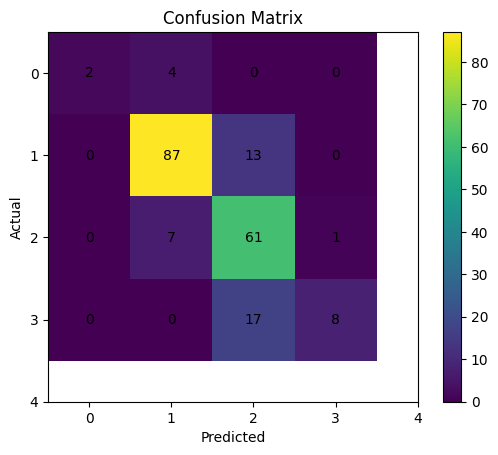

In [21]:
# Confusion Matrix (Random Forest)
cm = confusion_matrix(y_test, rf_pred)

plt.imshow(cm)
plt.title('Confusion Matrix')
plt.colorbar()

ticks = np.arange(len(np.unique(y)))
plt.xticks(ticks, np.unique(y))
plt.yticks(ticks, np.unique(y))

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


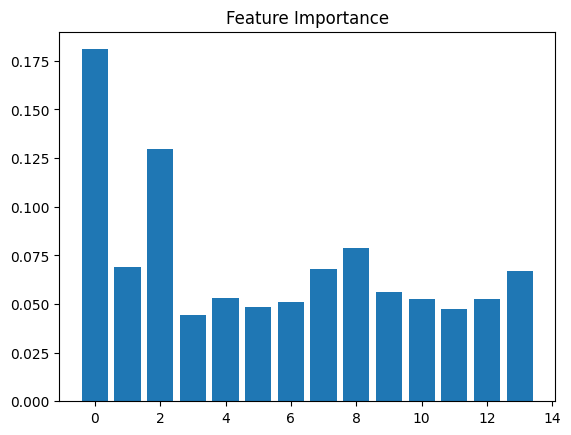

In [22]:
# Feature Importance (Random Forest)
importances = rf.feature_importances_

plt.bar(range(len(importances)), importances)
plt.title('Feature Importance')
plt.show()


In [23]:
# Save model
import joblib
joblib.dump(rf, 'geopolitical_model.pkl')


['geopolitical_model.pkl']

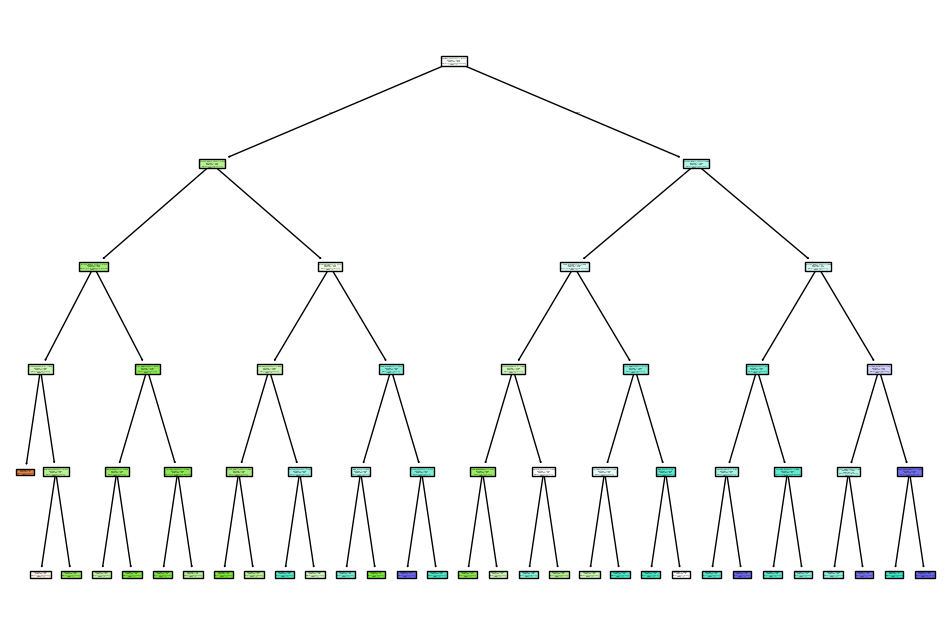

In [17]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(
    dt,
    feature_names=df.columns[:-1],
    class_names=[str(i) for i in sorted(y.unique())],
    filled=True
)
plt.show()